# 02. Model Diagnostics

핵심목표

1. 모델별 전체 성능 비교
2. 클래스별 성능 차이 확인
3. Val-Test 차이 기반 과적합 점검
4. 튜닝 과정과 학습 곡선 확인


## 그래프

1. 모델별 Val/Test 성능 비교
2. 모델별 일반화 격차(Val-Test) 비교
3. Test 기준 클래스별 F1-score 비교
4. Test 기준 클래스별 Recall 비교
5. 튜닝 또는 후처리 개선 효과 비교
6. SVM C 탐색 곡선
7. LightGBM Optuna 탐색 결과
8. 저장된 학습 곡선 및 예측 결과 이미지 확인
9. Stage 간 분리도 2D 투영도 (PCA)
10. Stage별 핵심 점수 프로파일 — 레이더 차트


In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["axes.unicode_minus"] = False

available_fonts = {f.name for f in fm.fontManager.ttflist}
font_candidates = ["NanumGothic", "AppleGothic", "Malgun Gothic", "DejaVu Sans"]
selected_font = next((font for font in font_candidates if font in available_fonts), "DejaVu Sans")
plt.rcParams["font.family"] = selected_font

ROOT = Path.cwd().resolve()
if not (ROOT / "models").exists():
    ROOT = ROOT.parent

MODELS_DIR = ROOT / "models"
OUT_DIR = ROOT / "outputs" / "figures" / "model_diagnostics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_LABELS = {
    "0": "1단계 완전 소외",
    "1": "2단계 부분 적응",
    "2": "3단계 자립 적응",
}

MODEL_ORDER = ["MLP", "LightGBM", "SVM"]
MODEL_COLORS = {
    "MLP": "#4C78A8",
    "LightGBM": "#F28E2B",
    "SVM": "#59A14F",
}

ROOT, OUT_DIR, selected_font


(PosixPath('/Users/minseo/Desktop/3-2/machine learning/Team-3'),
 PosixPath('/Users/minseo/Desktop/3-2/machine learning/Team-3/outputs/figures/model_diagnostics'),
 'AppleGothic')

In [2]:
def save_fig(filename: str):
    plt.tight_layout(rect=[0, 0, 1, 0.96], pad=1.2)
    plt.savefig(OUT_DIR / filename, bbox_inches="tight", facecolor="white")
    plt.show()


def apply_common_style(ax, grid_axis="y"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grid_axis, linestyle="--", alpha=0.25)


def set_axis_text(ax, title, xlabel, ylabel, title_size=18):
    ax.set_title(title, fontsize=title_size, fontweight="bold", pad=16)
    ax.set_xlabel(xlabel, fontweight="bold", labelpad=10)
    ax.set_ylabel(ylabel, fontweight="bold", labelpad=10)


def add_bar_values(ax, decimals=3, suffix=""):
    for bar in ax.patches:
        height = bar.get_height()
        if pd.isna(height) or height <= 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.{decimals}f}{suffix}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )


def parse_evaluation_file(path: Path, model_name: str):
    text = path.read_text(encoding="utf-8-sig")
    blocks = re.findall(
        r"(?P<split>validation|test) 평가 결과.*?Accuracy\s*:\s*(?P<accuracy>\d+\.\d+)\n"
        r"F1 macro\s*:\s*(?P<f1_macro>\d+\.\d+)\n"
        r"F1 weighted:\s*(?P<f1_weighted>\d+\.\d+)(?P<report>.*?)(?=(?:\n={10,})|\Z)",
        text,
        flags=re.S,
    )
    overall_rows = []
    class_rows = []
    for split_name, accuracy, f1_macro, f1_weighted, report in blocks:
        overall_rows.append(
            {
                "model": model_name,
                "split": split_name,
                "accuracy": float(accuracy),
                "f1_macro": float(f1_macro),
                "f1_weighted": float(f1_weighted),
            }
        )
        for line in report.splitlines():
            m = re.match(r"\s*(\d)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)", line)
            if m:
                cls, prec, rec, f1, support = m.groups()
                class_rows.append(
                    {
                        "model": model_name,
                        "split": split_name,
                        "class_id": cls,
                        "class_label": CLASS_LABELS.get(cls, cls),
                        "precision": float(prec),
                        "recall": float(rec),
                        "f1_score": float(f1),
                        "support": int(support),
                    }
                )
    return pd.DataFrame(overall_rows), pd.DataFrame(class_rows)


def load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8-sig"))


In [3]:
overall_frames = []
class_frames = []

for model_name, eval_path in {
    "MLP": MODELS_DIR / "MLP" / "MLP_evaluation.txt",
    "LightGBM": MODELS_DIR / "LightGBM" / "LightGBM_evaluation.txt",
    "SVM": MODELS_DIR / "SVM" / "SVM_evaluation.txt",
}.items():
    overall_df, class_df = parse_evaluation_file(eval_path, model_name)
    overall_frames.append(overall_df)
    class_frames.append(class_df)

overall_metrics = pd.concat(overall_frames, ignore_index=True)
class_metrics = pd.concat(class_frames, ignore_index=True)

overall_metrics["model"] = pd.Categorical(overall_metrics["model"], MODEL_ORDER, ordered=True)
class_metrics["model"] = pd.Categorical(class_metrics["model"], MODEL_ORDER, ordered=True)

svm_summary = load_json(MODELS_DIR / "SVM" / "svm_summary.json")
lgbm_summary = load_json(MODELS_DIR / "LightGBM" / "lgbm_summary.json")
svm_grid = pd.read_csv(MODELS_DIR / "SVM" / "svm_gridsearch_results.csv")
lgbm_trials = pd.read_csv(MODELS_DIR / "LightGBM" / "lgbm_optuna_trials.csv")
mlp_two_stage = pd.read_csv(MODELS_DIR / "MLP" / "MLP_two_stage_comparison.csv")

overall_metrics.sort_values(["split", "model"])


,model,split,accuracy,f1_macro,f1_weighted
1,MLP,test,0.9748,0.9751,0.9747
3,LightGBM,test,0.9788,0.9790,0.9788
5,SVM,test,0.9925,0.9926,0.9925
0,MLP,validation,0.9788,0.9785,0.9787
2,LightGBM,validation,0.9826,0.9826,0.9826
4,SVM,validation,0.9938,0.9937,0.9938


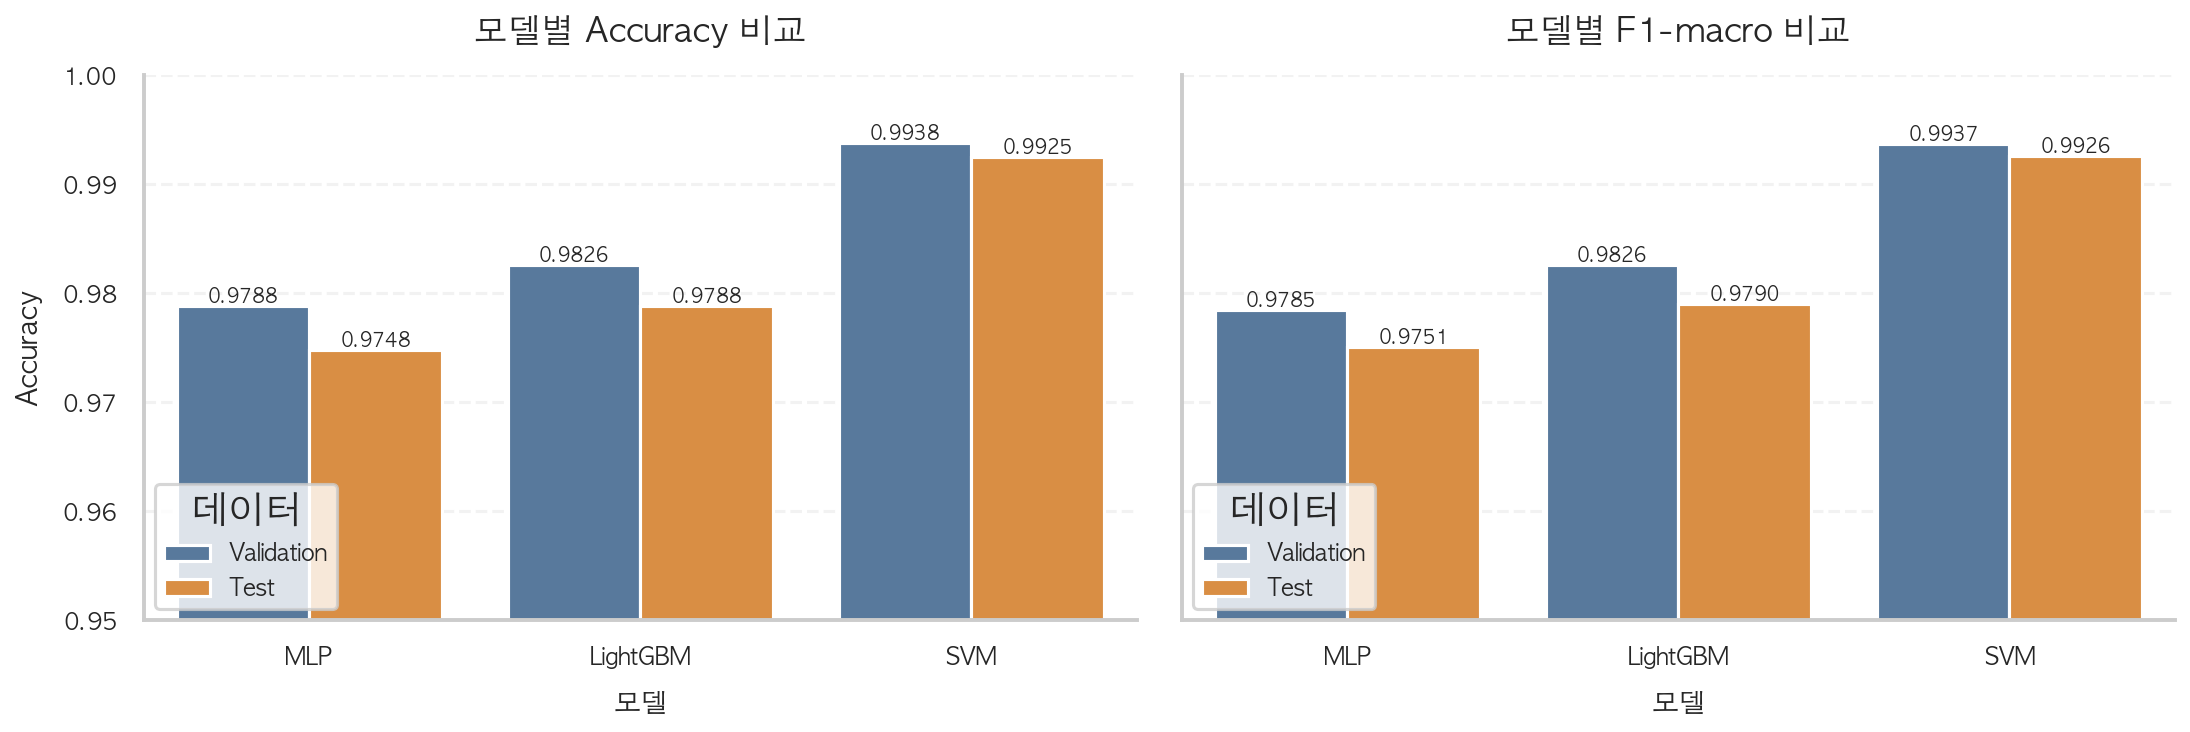

In [4]:
# 1. 모델별 Val/Test 성능 비교
plot_df = overall_metrics.melt(
    id_vars=["model", "split"],
    value_vars=["accuracy", "f1_macro"],
    var_name="metric",
    value_name="value",
)
plot_df["metric_label"] = plot_df["metric"].map({"accuracy": "Accuracy", "f1_macro": "F1-macro"})
plot_df["split_label"] = plot_df["split"].map({"validation": "Validation", "test": "Test"})

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, metric_name in zip(axes, ["Accuracy", "F1-macro"]):
    sub = plot_df[plot_df["metric_label"] == metric_name]
    sns.barplot(data=sub, x="model", y="value", hue="split_label", palette=["#4C78A8", "#F28E2B"], ax=ax)
    set_axis_text(ax, f"모델별 {metric_name} 비교", "모델", metric_name, title_size=16)
    ax.set_ylim(0.95, 1.0)
    apply_common_style(ax)
    add_bar_values(ax, decimals=4)
    ax.legend(title="데이터", loc="lower left")

save_fig("01_overall_metric_comparison.png")


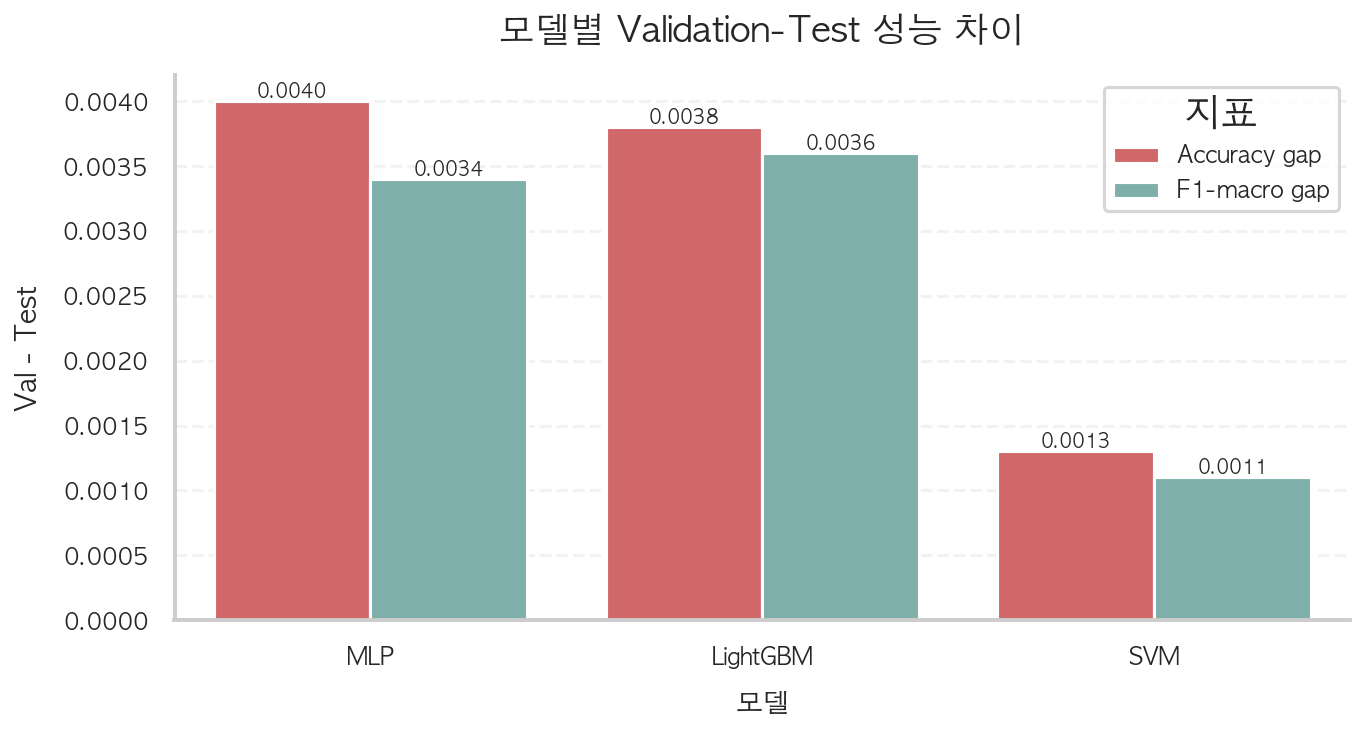

,model,accuracy_gap,f1_gap
0,MLP,0.0040,0.0034
1,LightGBM,0.0038,0.0036
2,SVM,0.0013,0.0011


In [5]:
# 2. 모델별 일반화 격차(Val-Test) 비교
val_metrics = overall_metrics[overall_metrics["split"] == "validation"][["model", "accuracy", "f1_macro"]].rename(
    columns={"accuracy": "val_accuracy", "f1_macro": "val_f1_macro"}
)
test_metrics = overall_metrics[overall_metrics["split"] == "test"][["model", "accuracy", "f1_macro"]].rename(
    columns={"accuracy": "test_accuracy", "f1_macro": "test_f1_macro"}
)
gap_df = val_metrics.merge(test_metrics, on="model", how="inner")
gap_df["accuracy_gap"] = gap_df["val_accuracy"] - gap_df["test_accuracy"]
gap_df["f1_gap"] = gap_df["val_f1_macro"] - gap_df["test_f1_macro"]

gap_plot = gap_df.melt(
    id_vars="model",
    value_vars=["accuracy_gap", "f1_gap"],
    var_name="gap_type",
    value_name="gap_value",
)
gap_plot["gap_label"] = gap_plot["gap_type"].map({"accuracy_gap": "Accuracy gap", "f1_gap": "F1-macro gap"})

plt.figure(figsize=(9.5, 5.5))
ax = sns.barplot(data=gap_plot, x="model", y="gap_value", hue="gap_label", palette=["#E15759", "#76B7B2"])
set_axis_text(ax, "모델별 Validation-Test 성능 차이", "모델", "Val - Test", title_size=17)
apply_common_style(ax)
add_bar_values(ax, decimals=4)
ax.legend(title="지표", loc="upper right")
save_fig("02_generalization_gap.png")

gap_df[["model", "accuracy_gap", "f1_gap"]]


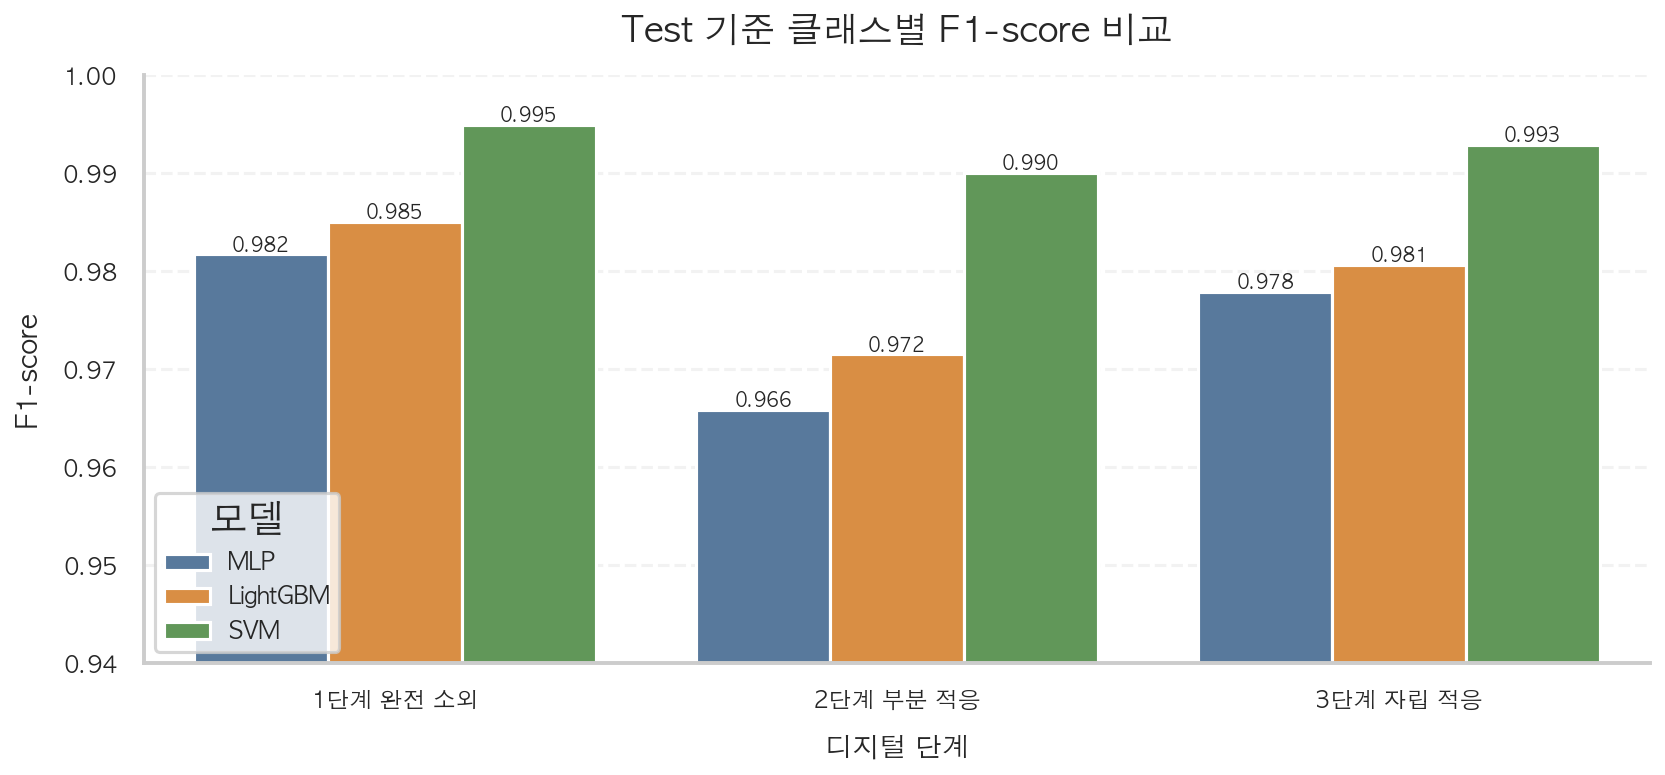

In [6]:
# 3. Test 기준 클래스별 F1-score 비교
test_class = class_metrics[class_metrics["split"] == "test"].copy()

plt.figure(figsize=(11.5, 5.8))
ax = sns.barplot(data=test_class, x="class_label", y="f1_score", hue="model", palette=MODEL_COLORS)
set_axis_text(ax, "Test 기준 클래스별 F1-score 비교", "디지털 단계", "F1-score", title_size=17)
ax.set_ylim(0.94, 1.0)
apply_common_style(ax)
add_bar_values(ax, decimals=3)
ax.legend(title="모델", loc="lower left")
save_fig("03_test_perclass_f1.png")


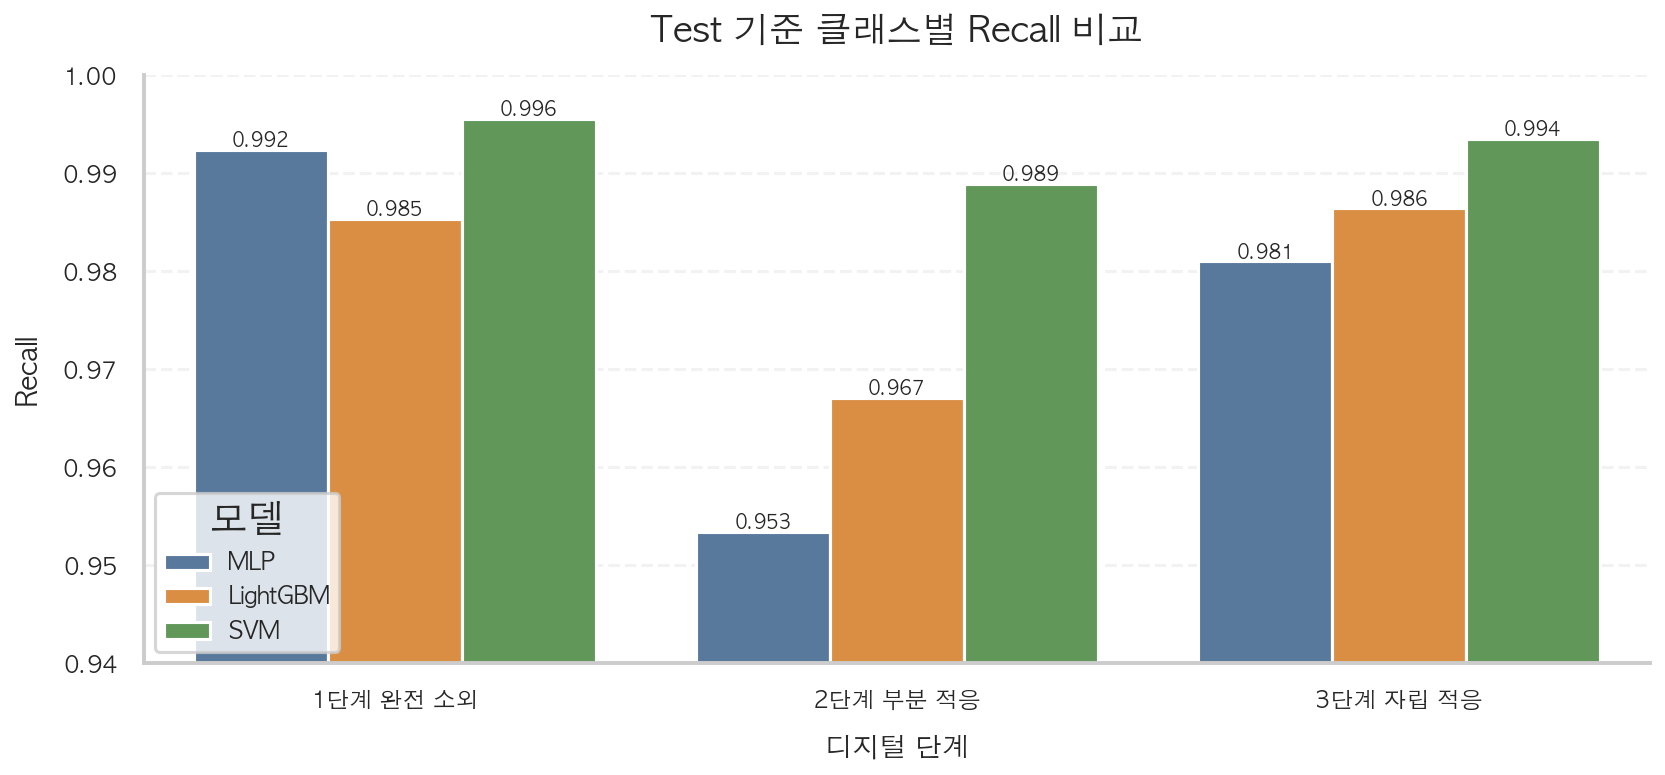

In [7]:
# 4. Test 기준 클래스별 Recall 비교
plt.figure(figsize=(11.5, 5.8))
ax = sns.barplot(data=test_class, x="class_label", y="recall", hue="model", palette=MODEL_COLORS)
set_axis_text(ax, "Test 기준 클래스별 Recall 비교", "디지털 단계", "Recall", title_size=17)
ax.set_ylim(0.94, 1.0)
apply_common_style(ax)
add_bar_values(ax, decimals=3)
ax.legend(title="모델", loc="lower left")
save_fig("04_test_perclass_recall.png")


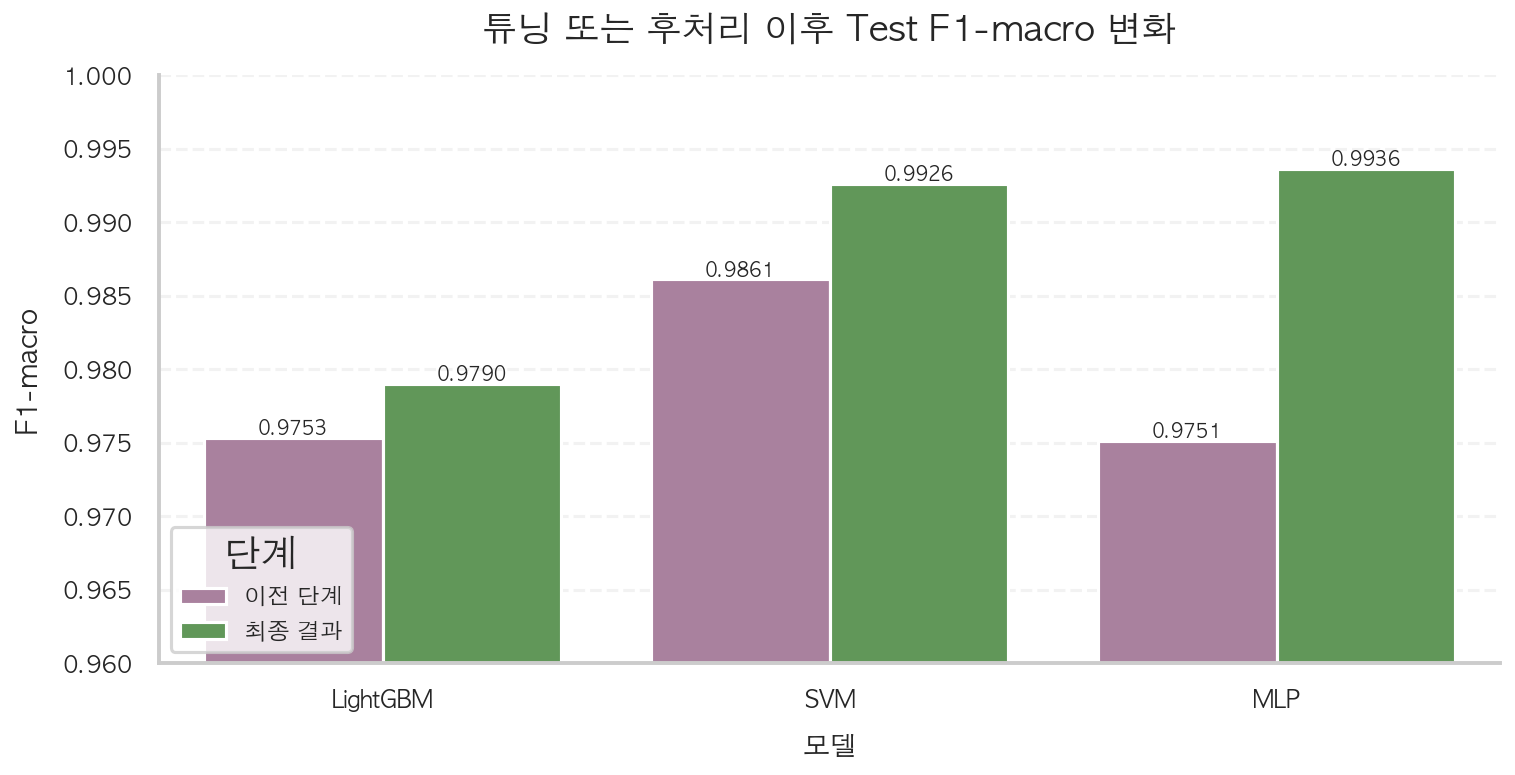

,model,baseline,final,experiment,delta
0,LightGBM,0.97530,0.979000,Baseline vs Tuned,0.003700
1,SVM,0.98610,0.992600,Baseline vs Tuned,0.006500
2,MLP,0.97511,0.993613,Stage1 vs Two-Stage,0.018503


In [8]:
# 5. 튜닝 또는 후처리 개선 효과 비교
improve_rows = [
    {
        "model": "LightGBM",
        "baseline": lgbm_summary["baseline_test_f1"],
        "final": lgbm_summary["tuned_test_f1"],
        "experiment": "Baseline vs Tuned",
    },
    {
        "model": "SVM",
        "baseline": svm_summary["baseline_test_f1"],
        "final": svm_summary["test_f1_macro"],
        "experiment": "Baseline vs Tuned",
    },
    {
        "model": "MLP",
        "baseline": float(mlp_two_stage.loc[mlp_two_stage["Model"] == "Stage1 MLP", "F1_macro"].iloc[0]),
        "final": float(mlp_two_stage.loc[mlp_two_stage["Model"] == "Two-Stage (Boundary Reclass)", "F1_macro"].iloc[0]),
        "experiment": "Stage1 vs Two-Stage",
    },
]
improve_df = pd.DataFrame(improve_rows)
improve_df["delta"] = improve_df["final"] - improve_df["baseline"]

improve_plot = improve_df.melt(id_vars=["model", "experiment", "delta"], value_vars=["baseline", "final"], var_name="phase", value_name="f1_macro")
improve_plot["phase_label"] = improve_plot["phase"].map({"baseline": "이전 단계", "final": "최종 결과"})

plt.figure(figsize=(10.5, 5.8))
ax = sns.barplot(data=improve_plot, x="model", y="f1_macro", hue="phase_label", palette=["#B07AA1", "#59A14F"])
set_axis_text(ax, "튜닝 또는 후처리 이후 Test F1-macro 변화", "모델", "F1-macro", title_size=17)
ax.set_ylim(0.96, 1.0)
apply_common_style(ax)
add_bar_values(ax, decimals=4)
ax.legend(title="단계", loc="lower left")
save_fig("05_improvement_summary.png")

improve_df


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

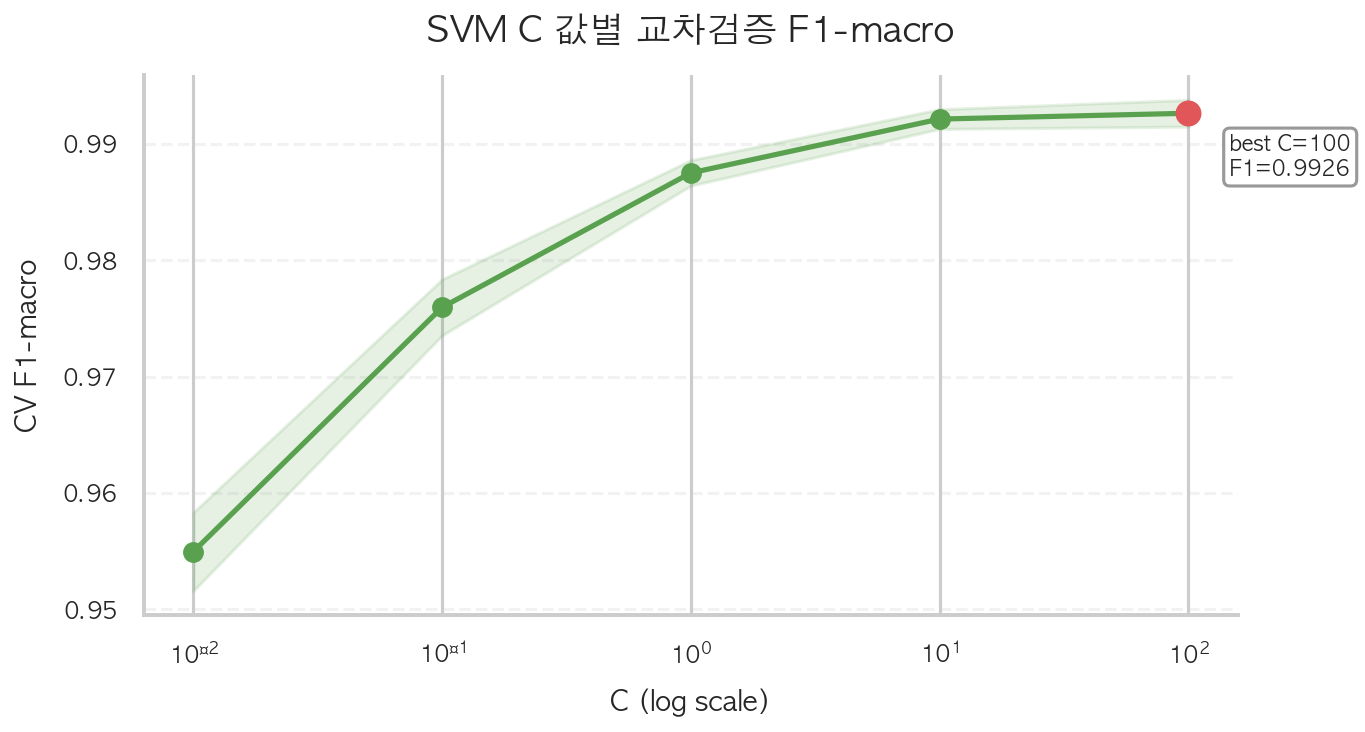

In [9]:
# 6. SVM C 탐색 곡선
plt.figure(figsize=(9.5, 5.5))
ax = plt.gca()
ax.plot(svm_grid["C"], svm_grid["mean_f1_macro"], marker="o", linewidth=2.5, color="#59A14F")
ax.fill_between(
    svm_grid["C"],
    svm_grid["mean_f1_macro"] - svm_grid["std_f1_macro"],
    svm_grid["mean_f1_macro"] + svm_grid["std_f1_macro"],
    color="#59A14F",
    alpha=0.15,
)
ax.set_xscale("log")
best_row = svm_grid.sort_values("rank").iloc[0]
ax.scatter(best_row["C"], best_row["mean_f1_macro"], s=120, color="#E15759", zorder=5)
ax.annotate(
    f"best C={best_row['C']:.0f}\nF1={best_row['mean_f1_macro']:.4f}",
    xy=(best_row["C"], best_row["mean_f1_macro"]),
    xytext=(20, -30),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#999999"),
)
set_axis_text(ax, "SVM C 값별 교차검증 F1-macro", "C (log scale)", "CV F1-macro", title_size=17)
apply_common_style(ax)
save_fig("06_svm_gridsearch_curve.png")


/var/folders/s9/zpmrzy2s4jj1yqn2l3wd4n6w0000gn/T/ipykernel_54052/3429170622.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="val_f1_macro", y="trial", palette="Oranges", ax=axes[1])


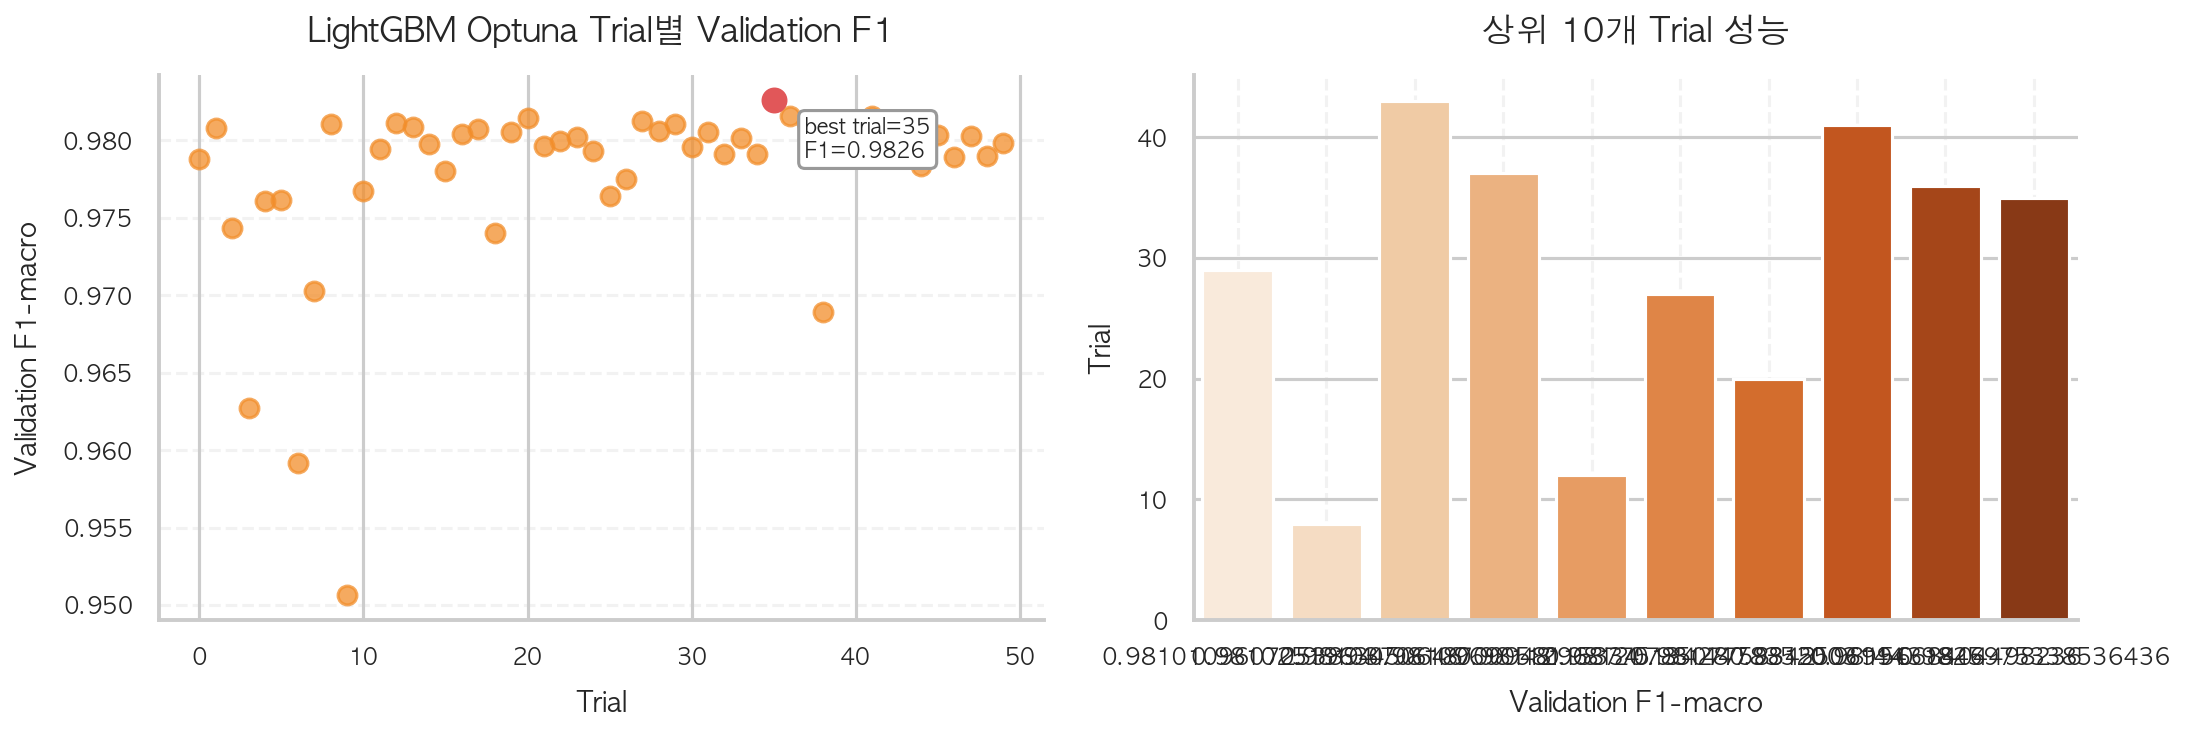

In [10]:
# 7. LightGBM Optuna 탐색 결과
trial_plot = lgbm_trials.copy().sort_values("val_f1_macro", ascending=False).reset_index(drop=True)
trial_plot["rank"] = np.arange(1, len(trial_plot) + 1)
best_trial = lgbm_trials.loc[lgbm_trials["val_f1_macro"].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].scatter(lgbm_trials["trial"], lgbm_trials["val_f1_macro"], color="#F28E2B", alpha=0.75)
axes[0].scatter(best_trial["trial"], best_trial["val_f1_macro"], color="#E15759", s=120, zorder=5)
axes[0].annotate(
    f"best trial={int(best_trial['trial'])}\nF1={best_trial['val_f1_macro']:.4f}",
    xy=(best_trial["trial"], best_trial["val_f1_macro"]),
    xytext=(15, -28),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#999999"),
)
set_axis_text(axes[0], "LightGBM Optuna Trial별 Validation F1", "Trial", "Validation F1-macro", title_size=16)
apply_common_style(axes[0])

top10 = trial_plot.head(10).sort_values("val_f1_macro")
sns.barplot(data=top10, x="val_f1_macro", y="trial", palette="Oranges", ax=axes[1])
set_axis_text(axes[1], "상위 10개 Trial 성능", "Validation F1-macro", "Trial", title_size=16)
apply_common_style(axes[1], grid_axis="x")

save_fig("07_lgbm_optuna_trials.png")


In [ ]:
# 9. Stage 간 분리도 2D 투영도 (PCA)
import sys
sys.path.insert(0, str(ROOT / "models"))
from model_config import MODEL_FEATURES
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

# 데이터 로드
_train = pd.read_csv(ROOT / "data" / "labeled" / "train_labeled.csv").assign(split="train")
_val   = pd.read_csv(ROOT / "data" / "labeled" / "val_labeled.csv").assign(split="val")
_test  = pd.read_csv(ROOT / "data" / "labeled" / "test_labeled.csv").assign(split="test")
_all   = pd.concat([_train, _val, _test], ignore_index=True)

available_feats = [f for f in MODEL_FEATURES if f in _all.columns]
X_all = _all[available_feats].fillna(0).values
y_all = _all["digital_stage"].values

X_scaled = StandardScaler().fit_transform(X_all)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 시각화
STAGE_COLORS = {1: "#E15759", 2: "#F28E2B", 3: "#4C78A8"}
STAGE_NAME   = {1: "1단계 완전 소외", 2: "2단계 부분 적응", 3: "3단계 자립 적응"}
SPLIT_MARKER = {"train": "o", "val": "s", "test": "^"}

fig, ax = plt.subplots(figsize=(11, 8))
for split_name, marker in SPLIT_MARKER.items():
    mask_s = (_all["split"] == split_name).values
    for stage_id, color in STAGE_COLORS.items():
        mask = mask_s & (y_all == stage_id)
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   color=color, marker=marker, alpha=0.35, s=18, edgecolors="none")

stage_handles = [
    Line2D([0], [0], marker="o", color=c, linestyle="None", markersize=9, label=STAGE_NAME[s])
    for s, c in STAGE_COLORS.items()
]
split_handles = [
    Line2D([0], [0], marker=m, color="gray", linestyle="None", markersize=8, label=f"{sp} set")
    for sp, m in SPLIT_MARKER.items()
]
l1 = ax.legend(handles=stage_handles, title="디지털 단계", loc="upper right", fontsize=10)
ax.add_artist(l1)
ax.legend(handles=split_handles, title="데이터 분할", loc="lower right", fontsize=10)

var1, var2 = pca.explained_variance_ratio_ * 100
set_axis_text(
    ax,
    f"Stage 간 분리도 — PCA 2D 투영\n(PC1 {var1:.1f}%, PC2 {var2:.1f}%)",
    f"PC1 ({var1:.1f}%)", f"PC2 ({var2:.1f}%)", title_size=16,
)
apply_common_style(ax, grid_axis="both")
save_fig("09_pca_stage_separation.png")


In [ ]:
# 10. Stage별 핵심 점수 프로파일 — 레이더 차트 (도메인별 정규화)
DOMAIN_FEATURES = {
    "기기\n접근성": ["Q1_1","Q1_2","Q2K2_1","Q2K2_2","Q3","Q4B_1_1","Q4B_2_1","Q4C_1","Q4C_2"],
    "기본\n역량":   ["Q5_1","Q5_2","Q5_3","Q5_4","Q5_5",
                    "Q6_1","Q6_2","Q6_3","Q6_4","Q6_5","Q6_6","Q6_7",
                    "Q7_1","Q7_2","Q7_3","Q7_4","Q7_5","Q7_6","Q7_7"],
    "종합\n활동":   ["Q8_1","Q8_2","Q8_3","Q8_4","Q8_5","Q8_6","Q8_7","Q8_8","Q8_9",
                    "Q9_1","Q9_2","Q9_3","Q9_4","Q9_5","Q9_6","Q9_7","Q9_8","Q9_9"],
    "서비스\n활용": ["Q10",
                    "Q12A_1","Q12A_2","Q12A_3","Q12A_4","Q12B_1","Q12B_2","Q12B_3","Q12B_4",
                    "Q13A_1","Q13A_2","Q13A_3","Q13A_4","Q13A_5",
                    "Q13B_1","Q13B_2","Q13B_3","Q13B_4","Q13B_5",
                    "Q14A_1","Q14A_2","Q14A_3","Q14A_4","Q14A_5",
                    "Q14B_1","Q14B_2","Q14B_3","Q14B_4","Q14B_5",
                    "Q15A_1","Q15A_2","Q15B_1","Q15B_2",
                    "Q16A_1","Q16A_2","Q16B_1","Q16B_2",
                    "Q17A_1","Q17A_2","Q17A_3","Q17A_4",
                    "Q17B_1","Q17B_2","Q17B_3","Q17B_4",
                    "Q18A_1","Q18A_2","Q18A_3","Q18A_4",
                    "Q18B_1","Q18B_2","Q18B_3","Q18B_4"],
    "사용\n시간":   ["Q11_1","Q11_2","Q11_3"],
    "AI\n관련":    ["Q19_1","Q19_2","Q19_3","Q19_4","Q19_5",
                    "Q21_1","Q21_2","Q21_3","Q21_4",
                    "Q22_1","Q22_2","Q22_3","Q22_4",
                    "AI_인지","AI_사용빈도","AI_도움정도"],
}

# 이미 로드된 all_df 재사용
_train2 = pd.read_csv(ROOT / "data" / "labeled" / "train_labeled.csv")
_val2   = pd.read_csv(ROOT / "data" / "labeled" / "val_labeled.csv")
_test2  = pd.read_csv(ROOT / "data" / "labeled" / "test_labeled.csv")
_all2   = pd.concat([_train2, _val2, _test2], ignore_index=True)

domain_scores = {}
for domain, feats in DOMAIN_FEATURES.items():
    avail = [f for f in feats if f in _all2.columns]
    if not avail:
        continue
    domain_scores[domain] = _all2.groupby("digital_stage")[avail].mean().mean(axis=1)

radar_df   = pd.DataFrame(domain_scores)
radar_norm = radar_df / radar_df.max()  # 각 도메인 최댓값(3단계) 기준 0~1 정규화

domains = radar_norm.columns.tolist()
N       = len(domains)
angles  = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

STAGE_COLORS = {1: "#E15759", 2: "#F28E2B", 3: "#4C78A8"}
STAGE_NAME   = {1: "1단계 완전 소외", 2: "2단계 부분 적응", 3: "3단계 자립 적응"}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for stage_id, color in STAGE_COLORS.items():
    vals = radar_norm.loc[stage_id].tolist() + [radar_norm.loc[stage_id].tolist()[0]]
    ax.plot(angles, vals, color=color, linewidth=2.2, label=STAGE_NAME[stage_id])
    ax.fill(angles, vals, color=color, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(domains, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=8)
ax.set_title("디지털 단계별 핵심 점수 프로파일\n(도메인별 정규화 · 3단계=100% 기준)", fontsize=16, fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=11)

save_fig("10_radar_stage_profile.png")


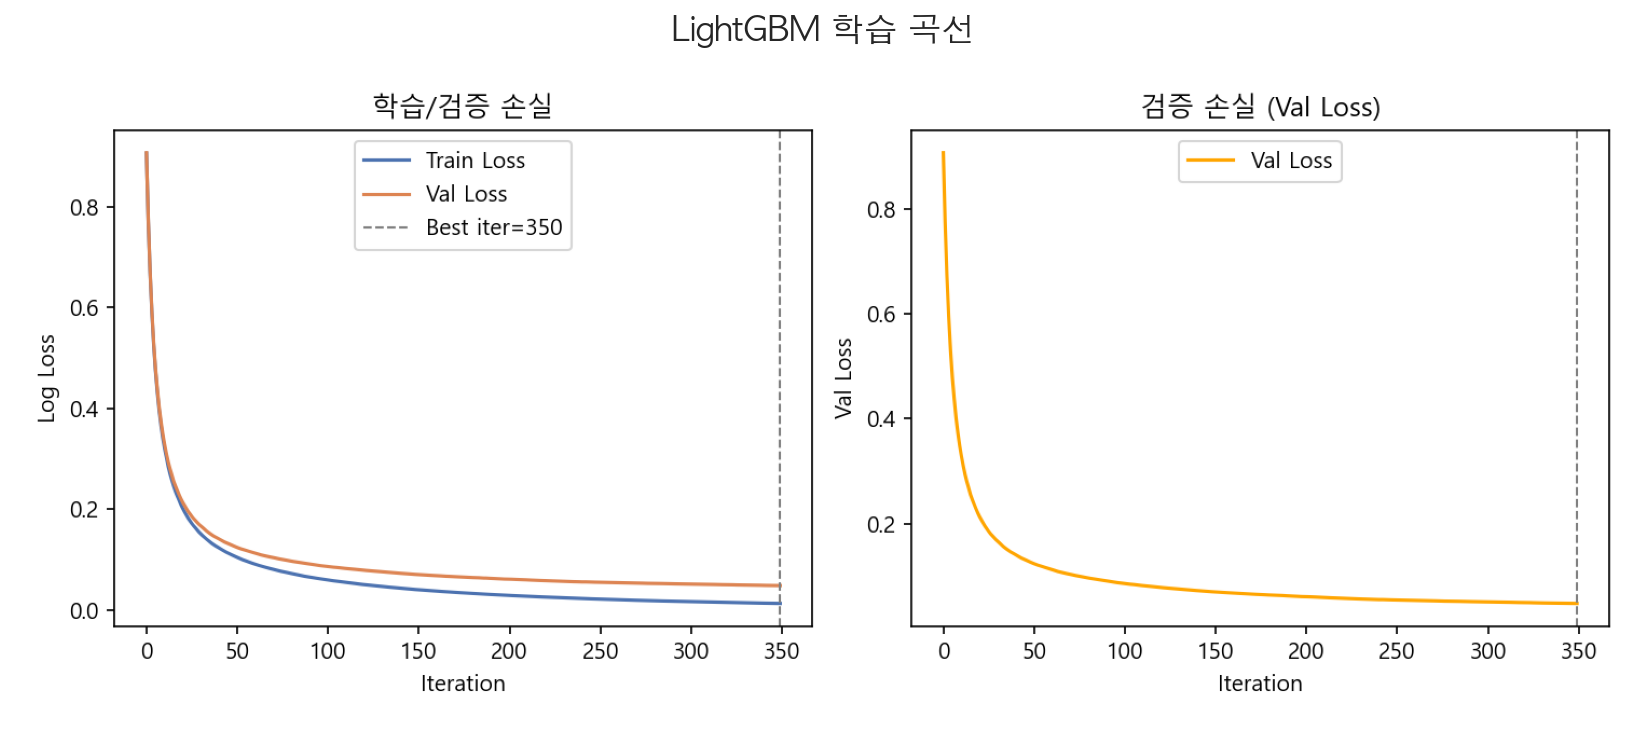

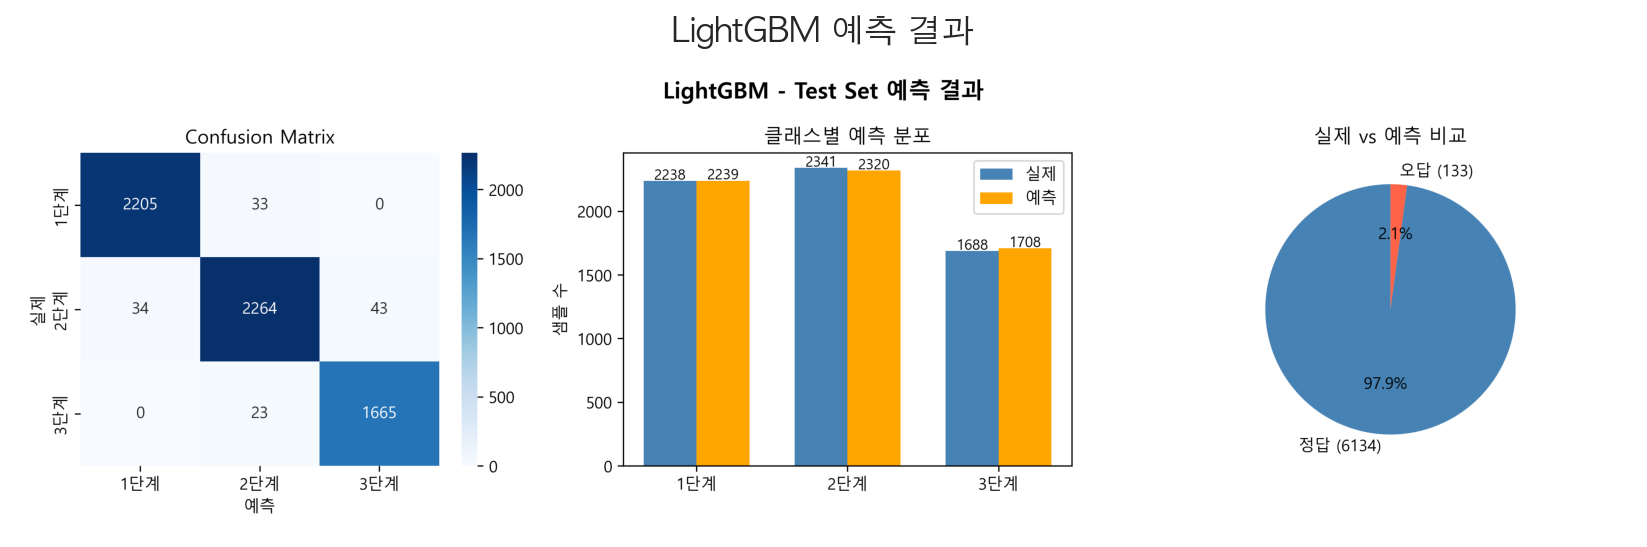

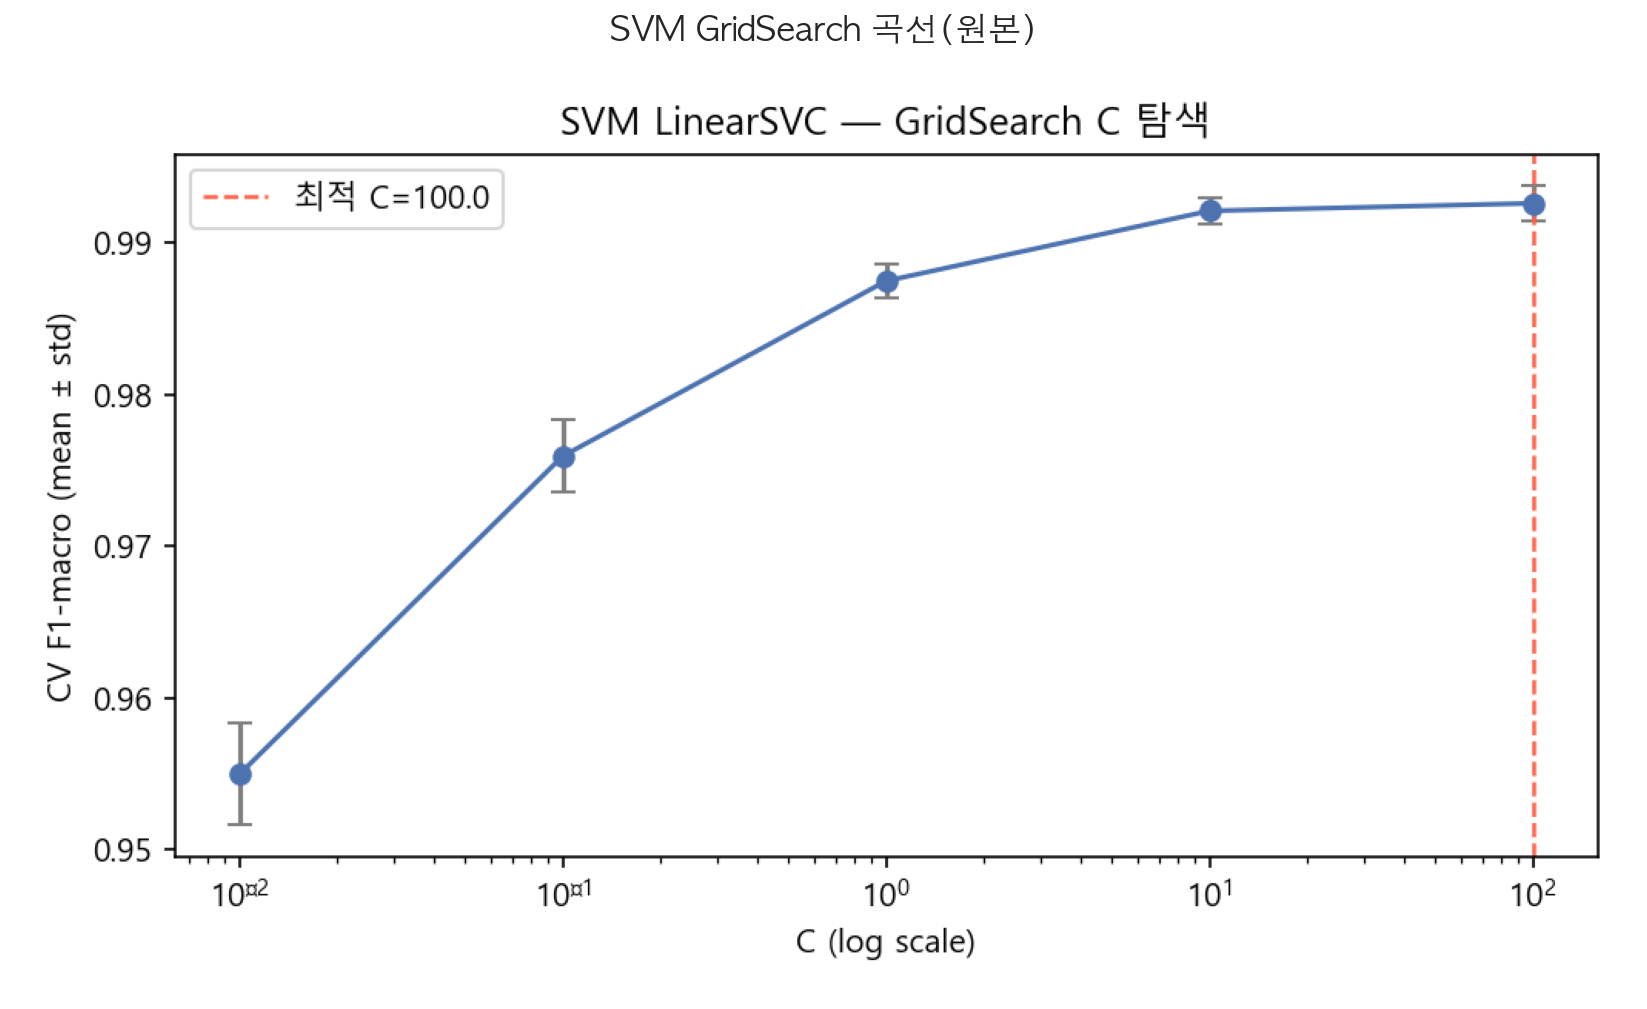

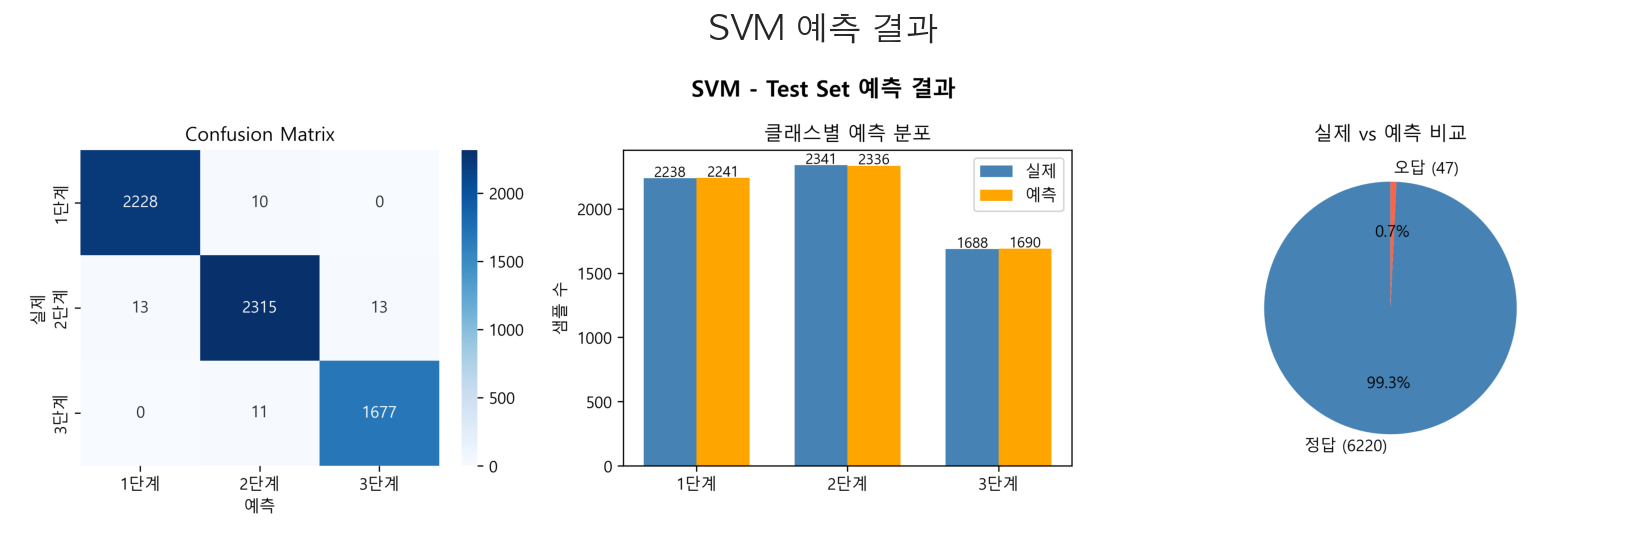

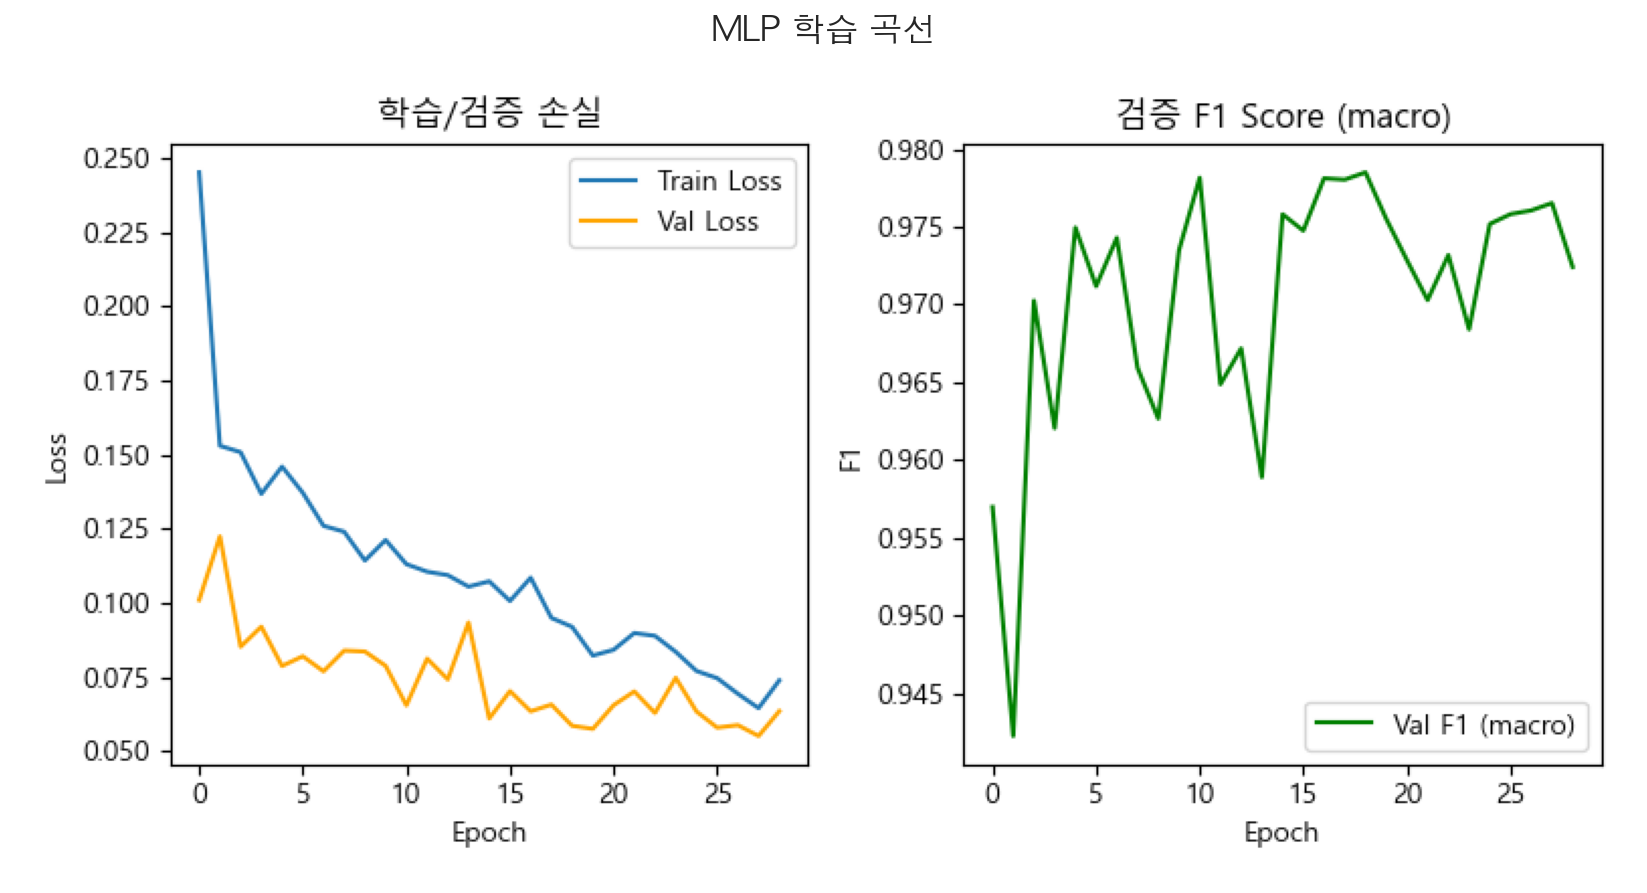

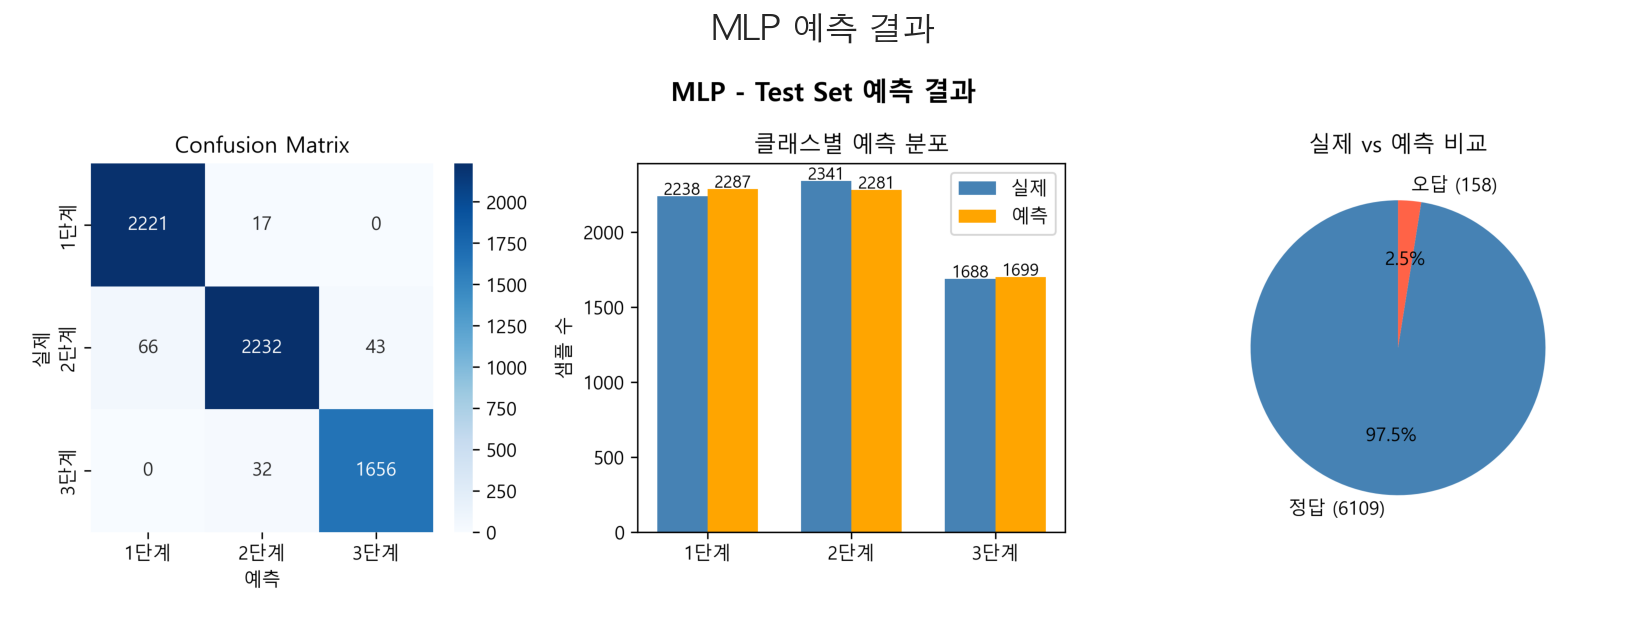

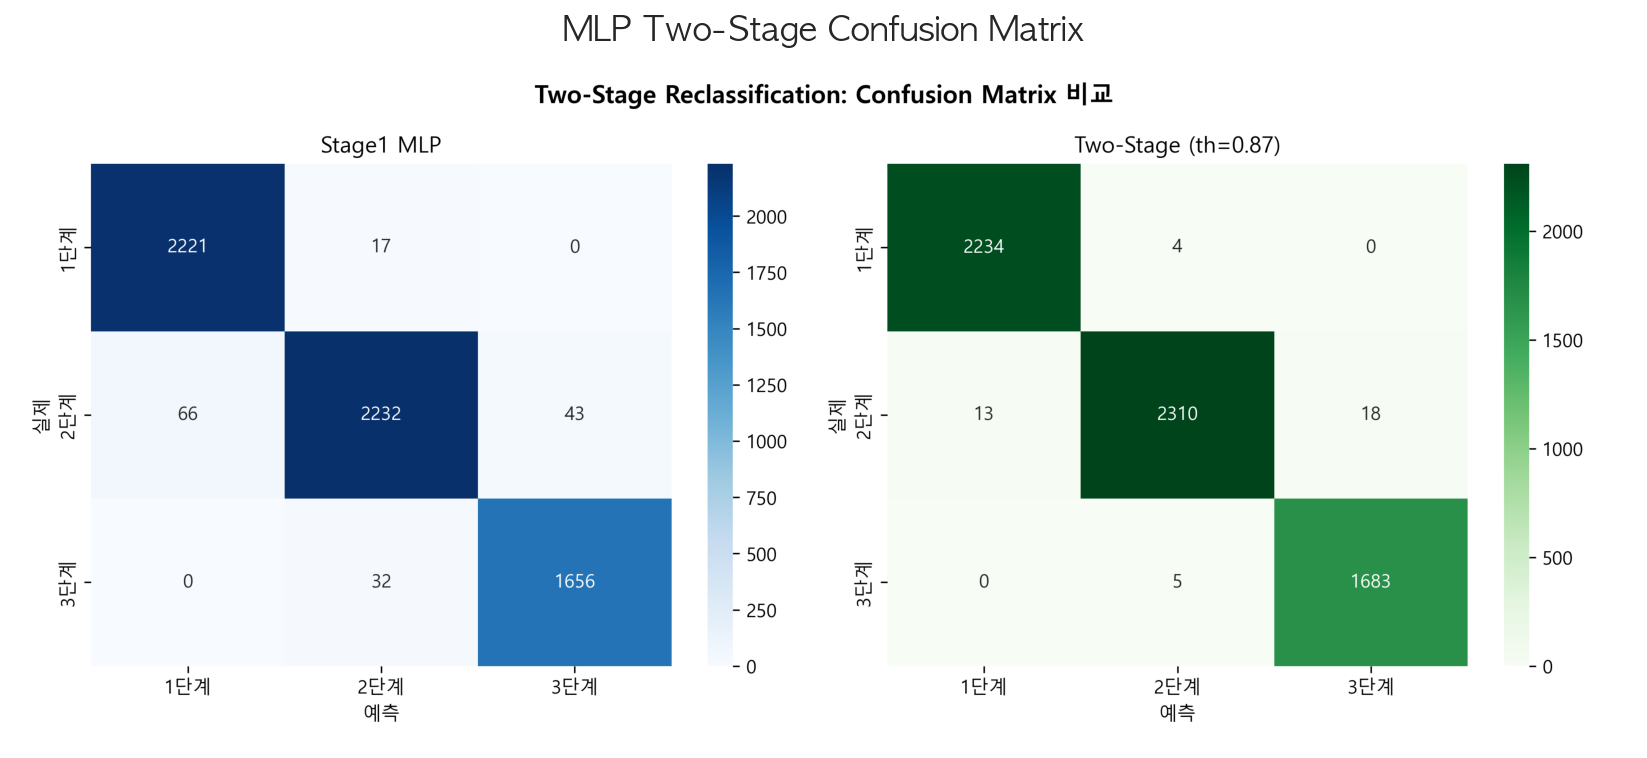

In [11]:
# 8. 저장된 학습 곡선 및 예측 결과 이미지 확인
from PIL import Image

image_candidates = {
    "LightGBM 학습 곡선": [MODELS_DIR / "LightGBM" / "lgbm_training_curve.png"],
    "LightGBM 예측 결과": [MODELS_DIR / "LightGBM" / "lgbm_prediction_results.png"],
    "SVM GridSearch 곡선(원본)": [MODELS_DIR / "SVM" / "svm_gridsearch_curve.png"],
    "SVM 예측 결과": [MODELS_DIR / "SVM" / "svm_prediction_results.png"],
    "MLP 학습 곡선": [MODELS_DIR / "MLP" / "training_curve.png"],
    "MLP 개선 전 예측 결과 (Stage1)": [MODELS_DIR / "MLP" / "MLP_prediction_results.png"],
    "MLP Two-Stage 예측 결과": [
        MODELS_DIR / "MLP" / "MLP_two_stage_rediction_results.png",
        MODELS_DIR / "MLP" / "MLP_two_stage_prediction_results.png",
    ],
    "MLP 개선 후 혼동행렬 (Two-Stage)": [MODELS_DIR / "MLP" / "MLP_two_stage_confusion_matrix.png"],
}

for title, candidates in image_candidates.items():
    path = next((candidate for candidate in candidates if candidate.exists()), None)
    if path is None:
        print(f"[missing] {title}: {candidates[0]}")
        continue
    img = Image.open(path)
    width, height = img.size
    fig_w = 14
    fig_h = fig_w * (height / width)
    plt.figure(figsize=(fig_w, fig_h))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title, fontsize=16, fontweight="bold", pad=14)
    plt.show()
